<a href="https://colab.research.google.com/github/Harshith-32920/Deep_Learning_Implementations/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Perceptron
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten,Conv2D
# Dense make sthe final prediction and Convo2D extracts features

from tensorflow.keras.layers import MaxPooling2D,Dropout
#dropout prevents overfittng
#maxPooling reduces size

from tensorflow.keras.utils import to_categorical #dataset to - onehot encoded data


In [4]:
from tensorflow.keras.datasets import mnist


In [5]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
df=mnist.load_data()

In [9]:
model = Sequential([
    # Feature Extraction
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Dropout(0.25),
    Flatten(),

    # Classification
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax') # 10 output classes for digits 0-9
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model (using a portion of training data for validation)
history = model.fit(X_train, y_train,
                    batch_size=128,
                    epochs=10,
                    validation_split=0.1)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 45s 102ms/step - accuracy: 0.8971 - loss: 0.3330 - val_accuracy: 0.9835 - val_loss: 0.0600
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 99ms/step - accuracy: 0.9672 - loss: 0.1082 - val_accuracy: 0.9868 - val_loss: 0.0426
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 81s 98ms/step - accuracy: 0.9764 - loss: 0.0779 - val_accuracy: 0.9892 - val_loss: 0.0386
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 102ms/step - accuracy: 0.9801 - loss: 0.0646 - val_accuracy: 0.9897 - val_loss: 0.0373
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 81s 99ms/step - accuracy: 0.9827 - loss: 0.0570 - val_accuracy: 0.9912 - val_loss: 0.0325
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 99ms/step - accuracy: 0.9846 - loss: 0.0505 - val_accuracy: 0.9913 - val_loss: 0.0308
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 100ms/step - accuracy: 0.9855 - loss: 0.0458 - val_accuracy: 0.9920 - val_loss: 0.0313
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 98ms/step - accuracy: 0.9871 - loss: 0.0418

In [11]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9927 - loss: 0.0215
Test Accuracy: 0.9927


**ANN**

In [13]:
ann=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax')
])

In [14]:
ann.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [19]:
# 1. Reload the original labels to reset them
(_, y_train), (_, y_test) = mnist.load_data()

# 2. One-hot encode the labels exactly ONCE
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print(f"Corrected y_train shape: {y_train.shape}") # Should print (60000, 10)

Corrected y_train shape: (60000, 10)


In [ ]:
ann_history = ann.fit(X_train, y_train,
                            batch_size=128,
                            epochs=10,
                            validation_split=0.1)

In [22]:
# 1. Reset and prepare the data explicitly for the ANN
(X_train_ann, y_train_ann), (X_test_ann, y_test_ann) = mnist.load_data()

# Normalize the images
X_train_ann = X_train_ann / 255.0
X_test_ann = X_test_ann / 255.0

# One-hot encode labels (exactly once)
y_train_ann = to_categorical(y_train_ann, 10)
y_test_ann = to_categorical(y_test_ann, 10)

# 2. Build a fresh ANN model
ann = Sequential([
    Flatten(input_shape=(28, 28)), # Matches the reset X_train_ann shape
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# 3. Compile the fresh model
ann.compile(optimizer='adam',
            loss='categorical_crossentropy',
            metrics=['accuracy'])

# 4. Train the model
print("Training fresh ANN...")
ann_history = ann.fit(X_train_ann, y_train_ann,
                      batch_size=128,
                      epochs=10,
                      validation_split=0.1)

Training fresh ANN...
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8971 - loss: 0.3613 - val_accuracy: 0.9497 - val_loss: 0.1650
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9579 - loss: 0.1438 - val_accuracy: 0.9668 - val_loss: 0.1120
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9699 - loss: 0.1000 - val_accuracy: 0.9712 - val_loss: 0.0973
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9775 - loss: 0.0763 - val_accuracy: 0.9747 - val_loss: 0.0945
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9811 - loss: 0.0613 - val_accuracy: 0.9795 - val_loss: 0.0803
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9850 - loss: 0.0491 - val_accuracy: 0.9780 - val_loss: 0.0808
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9881 - loss: 0.0388 - val_accuracy: 0.9752 - val_loss: 0.0988
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9904 - loss: 0.0

Plotting

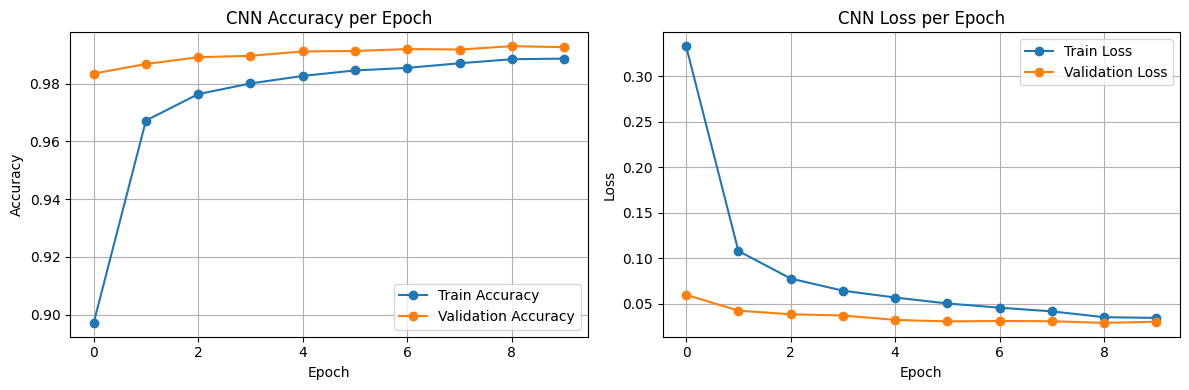

In [24]:
plt.figure(figsize=(12, 4))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('CNN Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('CNN Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


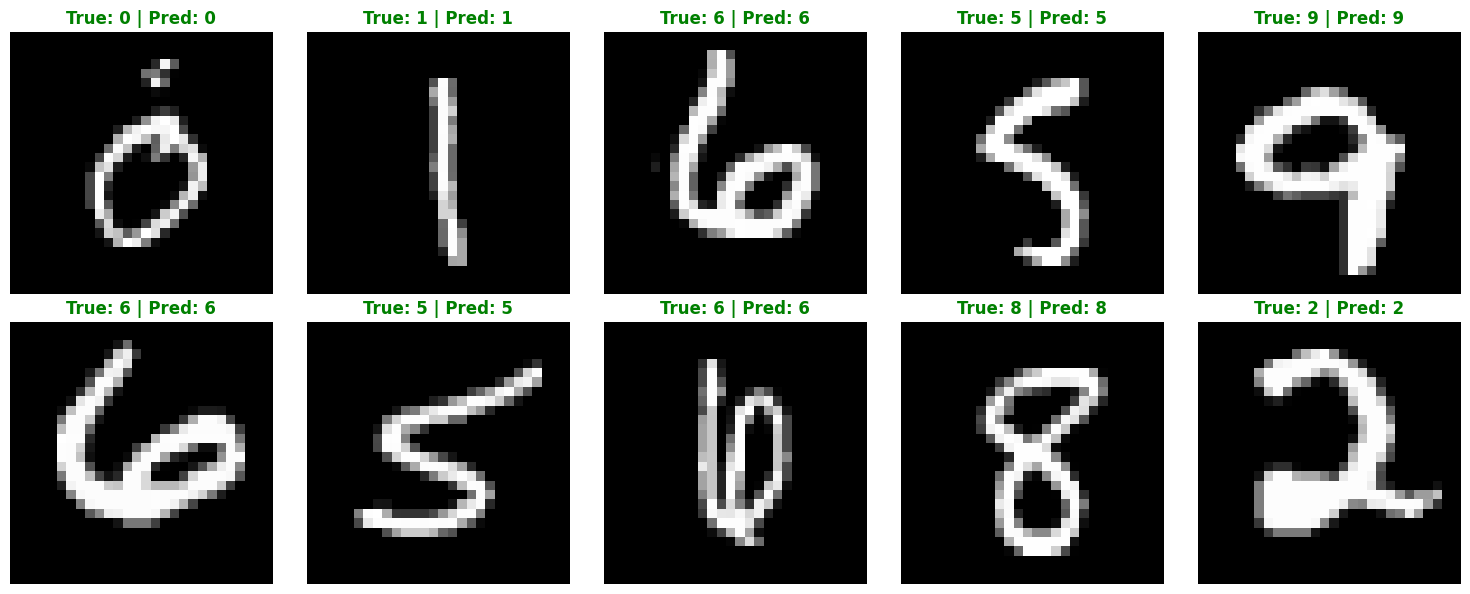

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate predictions using your trained CNN 'model'
predictions = model.predict(X_test)

# 2. Set up the plotting figure
plt.figure(figsize=(15, 6))
num_images = 10  # Number of predictions to visualize

# 3. Pick random images from the test set to display
random_indices = np.random.choice(len(X_test), num_images, replace=False)

for i, idx in enumerate(random_indices):
    plt.subplot(2, 5, i + 1)

    # Reshape the image array back to 28x28 pixels for plotting
    plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')

    # Convert one-hot encoded arrays back to single integer digits (0-9)
    true_label = np.argmax(y_test[idx])
    predicted_label = np.argmax(predictions[idx])

    # Color the title green if correct, red if incorrect
    text_color = 'green' if true_label == predicted_label else 'red'

    plt.title(f"True: {true_label} | Pred: {predicted_label}", color=text_color, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()